<a href="https://colab.research.google.com/github/reehabjahangir3-coder/THzScattering/blob/main/THzResonances_batchprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Batch Processing of FFT THz waveforms
This notebook is for the batch processing of time series data for aerated alumina suspensions.


###Import all files into a folder (air, empty cell, suspensions time-series)

###Functions of notebook
1.   Plot frequency domain spectra
2.   Calculate Refractive Index and filter out time series' for manual recalculation
4.   Calculate Absorption Coefficient in cm^-1

In [2]:
#import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [192]:
#INSPECT DATA AND CHECK UNITS
pd.options.display.max_rows = 5

#Change filepaths as necessary
df_emptycell = pd.read_csv('/content/1x0/emptycell.spectr.csv')
df_suspensions = pd.read_csv('/content/1x0/11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv')

# Clean column names by stripping whitespace
df_emptycell.columns = df_emptycell.columns.str.strip()
df_suspensions.columns = df_suspensions.columns.str.strip()

print(df_emptycell)
print(df_suspensions)

     Frequency/GHz  Amplitude rel.      Phase
0              0.0        0.002156   -0.00000
1             14.3        0.020957    0.42200
..             ...             ...        ...
699         9985.7        0.000010  495.77855
700        10000.0        0.000010  496.37164

[701 rows x 3 columns]
     Frequency/GHz  Amplitude rel.      Phase
0              0.0        0.000761   -3.14159
1             14.3        0.014059   -2.60018
..             ...             ...        ...
699         9985.7        0.000222  809.85615
700        10000.0        0.000063  810.53090

[701 rows x 3 columns]


### Sort files in chronological order according to timestamps in filename

In [193]:
#SORT FILES ACCORDING TO TIME-STAMPS
import glob
import re
import os

#Change directory as needed
directory = '/content/1x0/'

# Define a more flexible pattern for suspension files and empty cell files
# This pattern extracts the time part (HH_MM_SS) from filenames for sorting
# It also handles files that might not have a timestamp like 'emptycell.spectr.csv'
file_pattern = r'.*?(\d{2}_\d{2}_\d{2})\.spectr\.csv$'
spectr_files_with_time = []

for filepath in glob.glob(os.path.join(directory, '*.spectr.csv')):
    filename = os.path.basename(filepath)
    match = re.search(file_pattern, filename)
    if match:
        time_str = match.group(1) # Extract HH_MM_SS
        spectr_files_with_time.append((time_str, filepath))
    else:
        # For files like 'emptycell.spectr.csv', assign a default time for sorting
        # Or handle them separately if they don't fit the chronological sequence
        # For now, let's put them at the beginning (or end) by assigning a placeholder time
        if 'emptycell' in filename:
            spectr_files_with_time.append(('00_00_00', filepath)) # Place at beginning
        else:
            spectr_files_with_time.append(('99_99_99', filepath)) # Place at end

# Sort the files based on the time string
spectr_files_with_time.sort(key=lambda x: x[0])

# Get just the sorted file paths
sorted_spectr_filepaths = [filepath for time_str, filepath in spectr_files_with_time]

print(f"Found {len(sorted_spectr_filepaths)} .spectr.csv files. Sorted order:")
for f in sorted_spectr_filepaths:
    print(os.path.basename(f))

Found 52 .spectr.csv files. Sorted order:
emptycell.spectr.csv
11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#1_70ps_1avr_14_18_24.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#2_70ps_1avr_14_18_34.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#3_70ps_1avr_14_18_45.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#4_70ps_1avr_14_18_56.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#5_70ps_1avr_14_19_07.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#6_70ps_1avr_14_19_18.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#7_70ps_1avr_14_19_29.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#8_70ps_1avr_14_19_40.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#9_70ps_1avr_14_19_50.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#10_70ps_1avr_14_20_01.spectr.csv
11-05-2025 aerated alumina suspensions1x0_#11_70ps_1avr_14_20_12.spectr.csv
11-05-2025 aerated alumina suspens

### Plotting Amplitude vs. Frequency for all Spectr Files

/tmp/ipykernel_4446/2251569356.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


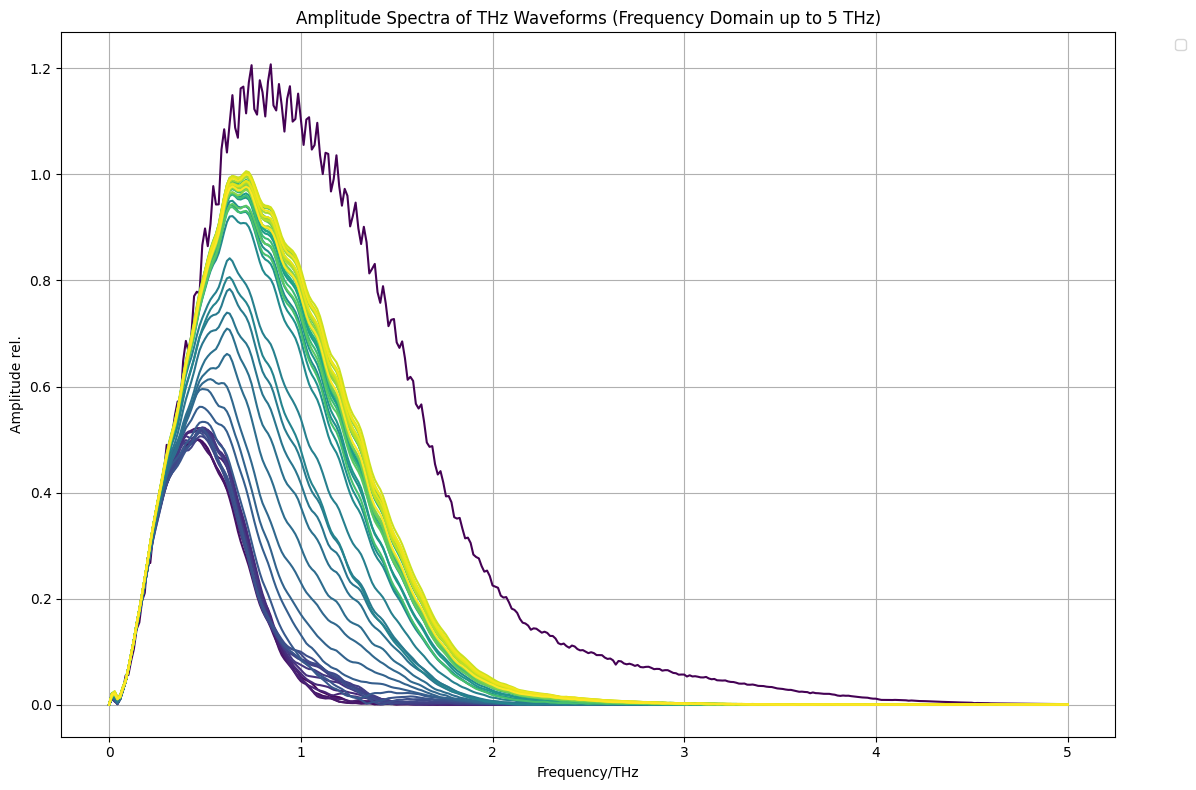

In [194]:
import matplotlib.cm as cm

plt.figure(figsize=(12, 8))

# Prepare colormap for the files
colors = cm.viridis(np.linspace(0, 1, len(sorted_spectr_filepaths)))

for i, filepath in enumerate(sorted_spectr_filepaths):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip() # Clean column names

    # Convert Frequency from GHz to THz and filter up to 5 THz
    df['Frequency/THz'] = df['Frequency/GHz'] / 1000
    df_filtered = df[df['Frequency/THz'] <= 5]

    filename = os.path.basename(filepath)
    # Extract timestamp for legend label
    match = re.search(r'(\d{2}_\d{2}_\d{2})\.spectr\.csv$', filename)
    if match:
        time_label = match.group(1).replace('_', ':')
        label = f'Time: {time_label}'
    elif 'emptycell' in filename:
        label = 'Empty Cell'
    else:
        label = filename.replace('.spectr.csv', '')

    plt.plot(df_filtered['Frequency/THz'], df_filtered['Amplitude rel.'], color=colors[i])

plt.xlabel('Frequency/THz')
plt.ylabel('Amplitude rel.')
plt.title('Amplitude Spectra of THz Waveforms (Frequency Domain up to 5 THz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels/legend from being cut off
plt.show()

### Download Amplitude vs frequency data as plotted in chronological order

In [208]:
amplitude_dfs_for_pivot = []

for filepath in sorted_spectr_filepaths[1:]: # Skip the empty cell file
    df_suspension = pd.read_csv(filepath)
    df_suspension.columns = df_suspension.columns.str.strip()

    # Convert Frequency from GHz to THz and filter up to 5 THz
    df_suspension['Frequency/THz'] = df_suspension['Frequency/GHz'] / 1000
    df_filtered_amplitude = df_suspension[df_suspension['Frequency/THz'] <= 5].copy()

    filename = os.path.basename(filepath)
    df_temp = df_filtered_amplitude[['Frequency/THz', 'Amplitude rel.']].copy()
    df_temp = df_temp.set_index('Frequency/THz')
    df_temp.rename(columns={'Amplitude rel.': filename}, inplace=True)
    amplitude_dfs_for_pivot.append(df_temp)

if amplitude_dfs_for_pivot:
    pivoted_amplitude_spectra_df = pd.concat(amplitude_dfs_for_pivot, axis=1, join='outer')
    pivoted_amplitude_spectra_df = pivoted_amplitude_spectra_df.reset_index() # Bring Frequency/THz back as a column
    print("Pivoted Amplitude Spectra Data (first 5 rows):\n")
    display(pivoted_amplitude_spectra_df.head())
    output_amp_csv_path = 'pivoted_amplitude_spectra.csv'
    pivoted_amplitude_spectra_df.to_csv(output_amp_csv_path, index=False)
    print(f"\nPivoted amplitude spectra data saved to '{output_amp_csv_path}'")
else:
    print("No amplitude spectra data to pivot.")

Pivoted Amplitude Spectra Data (first 5 rows):



,Frequency/THz,11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#1_70ps_1avr_14_18_24.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#2_70ps_1avr_14_18_34.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#3_70ps_1avr_14_18_45.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#4_70ps_1avr_14_18_56.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#5_70ps_1avr_14_19_07.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#6_70ps_1avr_14_19_18.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#7_70ps_1avr_14_19_29.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#8_70ps_1avr_14_19_40.spectr.csv,...,11-05-2025 aerated alumina suspensions1x0_#41_70ps_1avr_14_25_35.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#42_70ps_1avr_14_25_46.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#43_70ps_1avr_14_25_57.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#44_70ps_1avr_14_26_07.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#45_70ps_1avr_14_26_18.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#46_70ps_1avr_14_26_29.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#47_70ps_1avr_14_26_40.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#48_70ps_1avr_14_26_50.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#49_70ps_1avr_14_27_01.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#50_70ps_1avr_14_27_12.spectr.csv
0,0.0000,0.000761,0.000250,0.000480,0.000133,0.000544,0.000604,0.000573,0.000586,0.000130,...,0.000587,0.001048,0.000511,0.000313,0.000354,0.000662,0.000713,0.000837,0.000522,0.000930
1,0.0143,0.014059,0.011917,0.013320,0.009999,0.012429,0.013656,0.015887,0.021330,0.011301,...,0.017149,0.021019,0.019623,0.018435,0.020323,0.016194,0.018810,0.019754,0.021188,0.018642
2,0.0286,0.007884,0.006644,0.008806,0.007317,0.007152,0.007223,0.009832,0.010783,0.009220,...,0.022782,0.023898,0.021680,0.021705,0.021281,0.021045,0.023312,0.025574,0.022894,0.020568
3,0.0429,0.003626,0.002580,0.001668,0.000948,0.004084,0.006052,0.001692,0.006848,0.000853,...,0.012586,0.012498,0.010556,0.011283,0.010099,0.011340,0.013815,0.014890,0.011032,0.010667
4,0.0571,0.012582,0.011933,0.012112,0.012082,0.010823,0.014562,0.009667,0.012384,0.009889,...,0.013704,0.017410,0.014727,0.015016,0.015082,0.013768,0.017735,0.016485,0.014382,0.015682



Pivoted amplitude spectra data saved to 'pivoted_amplitude_spectra.csv'


### Calculating Refractive Index

To calculate the refractive index (n) of the suspensions, we will use the following formula, which relates the phase difference between the empty cell and the sample, the frequency, the speed of light, and the sample thickness:

$$n = 1 + \frac{\Delta\phi \cdot c}{2\pi \cdot f \cdot d}$$

Where:
*   $\Delta\phi$ is the phase difference between the sample and the empty cell.
*   $c$ is the speed of light in vacuum.
*   $f$ is the frequency in Hz.
*   $d$ is the thickness of the sample (set accordingly)

We will also need to define a helper function to calculate the slope of the refractive index curve around 0.5 THz.

In [196]:
from scipy.stats import linregress

# Define constants
c = 299792458 # Speed of light in m/s
d_cm = 1.12 # Thickness of the sample in cm; change accordingly
d = d_cm / 100 # Thickness of the sample in meters

# Define a function to calculate the slope within a specific frequency window
def calculate_slope_at_0_5_thz(df_ri, target_freq_thz=0.5, window_size_thz=0.1):
    if 'Frequency/THz' not in df_ri.columns:
        df_ri['Frequency/THz'] = df_ri['Frequency/GHz'] / 1000
    df_n_sorted = df_ri.sort_values(by='Frequency/THz').dropna(subset=['Refractive Index'])

    freq_min = target_freq_thz - window_size_thz / 2
    freq_max = target_freq_thz + window_size_thz / 2
    df_window = df_n_sorted[(df_n_sorted['Frequency/THz'] >= freq_min) & (df_n_sorted['Frequency/THz'] <= freq_max)]

    if len(df_window) >= 2:
        x = df_window['Frequency/THz'].values
        y = df_window['Refractive Index'].values
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        return slope
    return np.nan

In [197]:
# Load the empty cell data (reference)
# Assuming the first file in sorted_spectr_filepaths is the empty cell
empty_cell_filepath = sorted_spectr_filepaths[0]
df_emptycell_ref = pd.read_csv(empty_cell_filepath)
df_emptycell_ref.columns = df_emptycell_ref.columns.str.strip()

# Convert Frequency from GHz to Hz for calculations
df_emptycell_ref['Frequency/Hz'] = df_emptycell_ref['Frequency/GHz'] * 1e9

# Filter frequency up to 5 THz (5000 GHz) as in the plotting cell
df_emptycell_ref_filtered = df_emptycell_ref[df_emptycell_ref['Frequency/GHz'] <= 5000].copy()
empty_cell_phase = df_emptycell_ref_filtered['Phase'].values
frequency_hz = df_emptycell_ref_filtered['Frequency/Hz'].values

In [198]:
# Dictionary to store refractive index data for each suspension
refractive_indices = {}

# Iterate through suspension files (skipping the empty cell file)
for filepath in sorted_spectr_filepaths[1:]:
    df_suspension = pd.read_csv(filepath)
    df_suspension.columns = df_suspension.columns.str.strip()

    df_suspension['Frequency/Hz'] = df_suspension['Frequency/GHz'] * 1e9
    df_suspension_filtered = df_suspension[df_suspension['Frequency/GHz'] <= 5000].copy()

    suspension_phase = df_suspension_filtered['Phase'].values

    # Ensure both phase arrays have the same length and frequencies match
    if len(suspension_phase) != len(empty_cell_phase):
        print(f"Warning: Mismatched data points for {os.path.basename(filepath)}. Skipping.")
        continue

    # Calculate phase difference (Delta_phi) without any k-correction
    delta_phi = suspension_phase - empty_cell_phase + 2*np.pi
    unwrapped_delta_phi = np.unwrap(delta_phi)

    # Calculate refractive index (n)
    n_values = np.zeros_like(frequency_hz, dtype=float)
    non_zero_freq_mask = frequency_hz != 0
    n_values[non_zero_freq_mask] = 1 + (unwrapped_delta_phi[non_zero_freq_mask] * c) / (2 * np.pi * frequency_hz[non_zero_freq_mask] * d)
    n_values[~non_zero_freq_mask] = np.nan

    # Store the results
    filename = os.path.basename(filepath)
    refractive_indices[filename] = pd.DataFrame({
        'Frequency/GHz': df_suspension_filtered['Frequency/GHz'],
        'Refractive Index': n_values
    })

print("Refractive Index calculations complete for all suspension files (uncorrected).")

# Display the first few rows of the refractive index for the first suspension file as an example
if refractive_indices:
    first_key = list(refractive_indices.keys())[0]
    print(f"\nFirst 5 rows of Refractive Index for {first_key}:\n")
    display(refractive_indices[first_key].head())

Refractive Index calculations complete for all suspension files (uncorrected).

First 5 rows of Refractive Index for 11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv:



,Frequency/GHz,Refractive Index
0,0.0,NaN
1,14.3,1.971490
2,28.6,1.504527
3,42.9,1.509594
4,57.1,1.558553


### Calculate slope - check which files have phase unwrapping errors, and manually recalculate

In [199]:
print("Calculating slopes of Refractive Index at 0.5 THz for all uncorrected files...")
uncorrected_slopes = {}
for filename, df_n in refractive_indices.items():
    # Add Frequency/THz column if not present, needed for calculate_slope_at_0_5_thz
    if 'Frequency/THz' not in df_n.columns:
        df_n['Frequency/THz'] = df_n['Frequency/GHz'] / 1000
    slope = calculate_slope_at_0_5_thz(df_n)
    uncorrected_slopes[filename] = slope
    print(f"- {os.path.basename(filename)}: {slope:.4f} (RI per THz)")

negative_slopes_uncorrected = [
    filename for filename, slope in uncorrected_slopes.items()
    if pd.notna(slope) and slope < 0 or slope > 0.10
]

print(f"\nFound {len(negative_slopes_uncorrected)} file(s) with large positive and negative slope at 0.5 THz in uncorrected data:")
if negative_slopes_uncorrected:
    for f in negative_slopes_uncorrected:
        print(f"- {os.path.basename(f)}")
else:
    print("No files found with large positive slope and negative slope in the uncorrected data.")

Calculating slopes of Refractive Index at 0.5 THz for all uncorrected files...
- 11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv: 0.0140 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#1_70ps_1avr_14_18_24.spectr.csv: 0.0142 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#2_70ps_1avr_14_18_34.spectr.csv: 0.0106 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#3_70ps_1avr_14_18_45.spectr.csv: 0.0119 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#4_70ps_1avr_14_18_56.spectr.csv: 0.0096 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#5_70ps_1avr_14_19_07.spectr.csv: 0.0100 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#6_70ps_1avr_14_19_18.spectr.csv: 0.1211 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#7_70ps_1avr_14_19_29.spectr.csv: 0.0159 (RI per THz)
- 11-05-2025 aerated alumina suspensions1x0_#8_70ps_1avr_14_19_40.spectr.csv: -0.0928 (RI per THz)
- 11-05-2025 aerated alumina suspensi

### Plot Refractive Index - CHECK PHASE UNWRAPPING ERROR


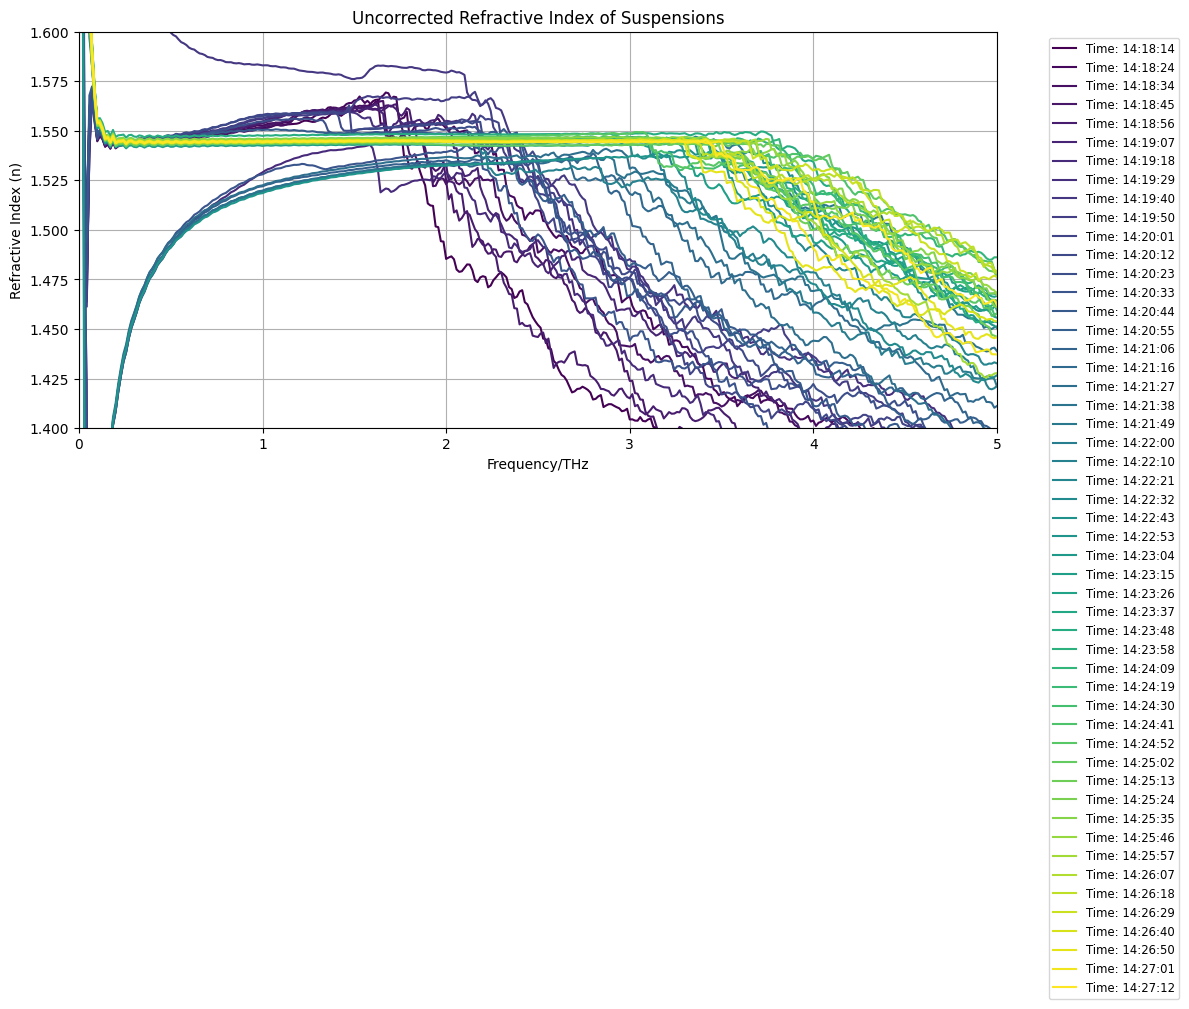

In [200]:
# Plot Uncorrected Refractive Index
plt.figure(figsize=(12, 8))

# Prepare colormap for the files
colors_uncorrected = cm.viridis(np.linspace(0, 1, len(refractive_indices)))

for i, (filename, df_n) in enumerate(refractive_indices.items()):
    df_n_filtered = df_n[df_n['Frequency/THz'] <= 5]

    match = re.search(r'(\d{2}_\d{2}_\d{2})\.spectr\.csv$', filename)
    if match:
        time_label = match.group(1).replace('_', ':')
        label = f'Time: {time_label}'
    else:
        label = filename.replace('.spectr.csv', '')

    plt.plot(df_n_filtered['Frequency/THz'], df_n_filtered['Refractive Index'],
             color=colors_uncorrected[i], label=label, linestyle='-') # Use solid line for all uncorrected plots

plt.xlabel('Frequency/THz')
plt.ylabel('Refractive Index (n)')
plt.title('Uncorrected Refractive Index of Suspensions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(1.4, 1.6)
plt.tight_layout()
plt.show()

### Save Filtered Refractive Index spectra into .csv files (sorted in chronological order)

### Calculating Absorption Coefficient

Now, let's calculate the absorption coefficient ($\alpha$) for each suspension. We will use the amplitude of the empty cell as a reference ($A_{ref}$) and the amplitude of each suspension ($A_{sample}$). Assuming a Fresnel transmission coefficient ($T$) of 1, the formula simplifies to:

$$\alpha = -\frac{1}{d} \ln\left(\frac{A_{sample}}{A_{ref}}\right)$$

Where:
*   $d$ is the thickness of the sample
*   $A_{sample}$ is the amplitude of the suspension.
*   $A_{ref}$ is the amplitude of the empty cell.

In [203]:
empty_cell_amplitude = df_emptycell_ref_filtered['Amplitude rel.'].values

absorption_coefficients = {}

for filepath in sorted_spectr_filepaths[1:]:
    df_suspension = pd.read_csv(filepath)
    df_suspension.columns = df_suspension.columns.str.strip()

    df_suspension_filtered = df_suspension[df_suspension['Frequency/GHz'] <= 5000].copy()

    suspension_amplitude = df_suspension_filtered['Amplitude rel.'].values

    if len(suspension_amplitude) != len(empty_cell_amplitude):
        print(f"Warning: Mismatched data points for {os.path.basename(filepath)}. Skipping.")
        continue

    # Calculate absorption coefficient (alpha)
    ratio = np.divide(suspension_amplitude, empty_cell_amplitude,
                      out=np.zeros_like(suspension_amplitude),
                      where=empty_cell_amplitude!=0)

    # Replace 0s in ratio with a small number to avoid log(0) and inf results
    ratio[ratio == 0] = np.finfo(float).eps

    alpha_values = - (1 / d_cm) * np.log(ratio)

    # Handle cases where ratio might be negative or nan after division
    alpha_values[np.isnan(alpha_values)] = 0  # Or another appropriate handling
    alpha_values[np.isinf(alpha_values)] = 0  # Or another appropriate handling

    filename = os.path.basename(filepath)
    absorption_coefficients[filename] = pd.DataFrame({
        'Frequency/GHz': df_suspension_filtered['Frequency/GHz'],
        'Absorption Coefficient (cm^-1)': alpha_values
    })

print("Absorption Coefficient calculations complete for all suspension files.")

if absorption_coefficients:
    first_key = list(absorption_coefficients.keys())[0]
    print(f"\nFirst 5 rows of Absorption Coefficient for {first_key}:\n")
    display(absorption_coefficients[first_key].head())

Absorption Coefficient calculations complete for all suspension files.

First 5 rows of Absorption Coefficient for 11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv:



,Frequency/GHz,Absorption Coefficient (cm^-1)
0,0.0,0.929433
1,14.3,0.356408
2,28.6,-0.266761
3,42.9,1.064682
4,57.1,0.360737


## Plot Absorption Coefficient

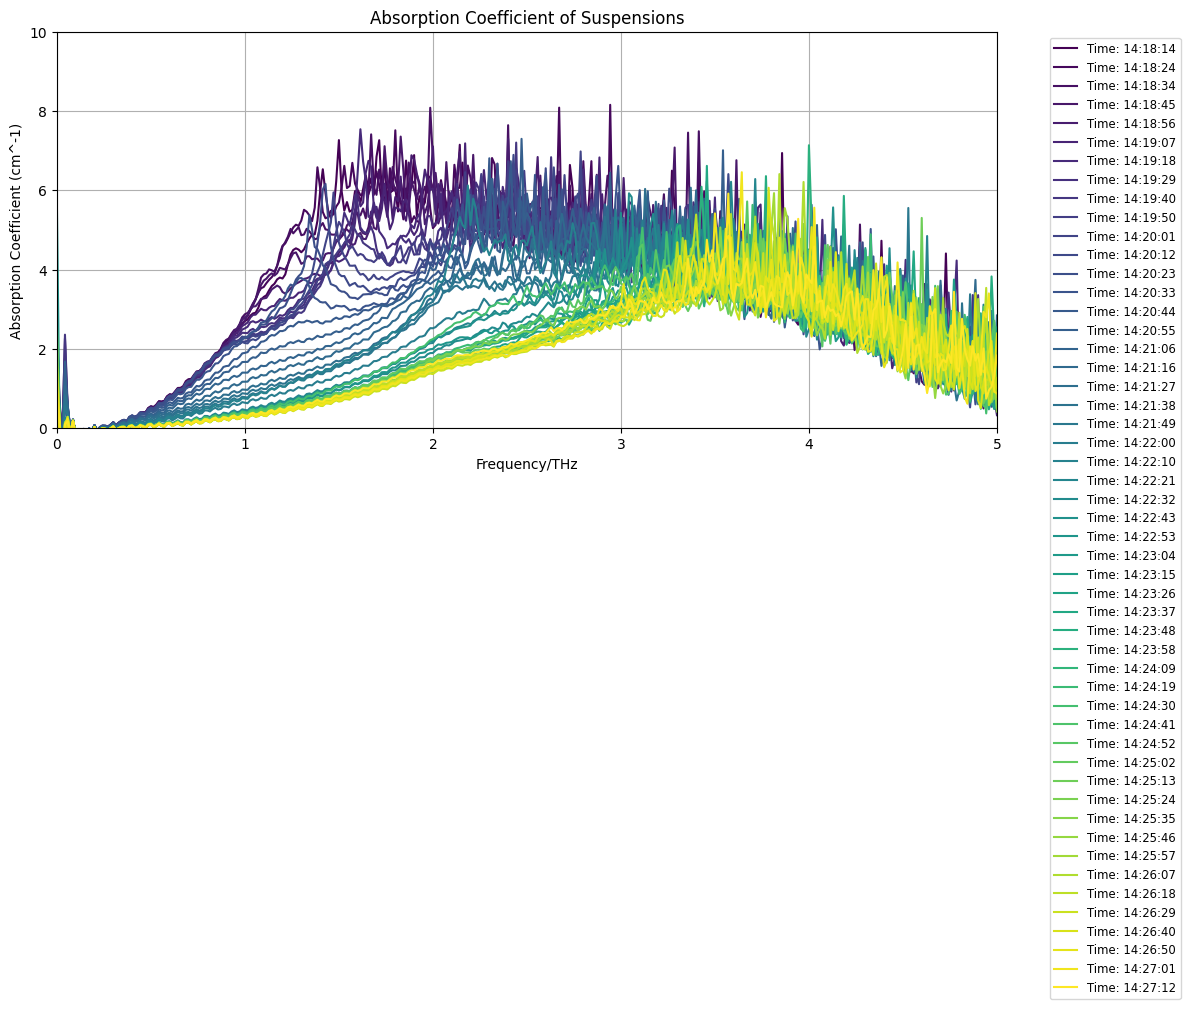

In [204]:
plt.figure(figsize=(12, 8))

# Prepare colormap for the files
colors_abs = cm.viridis(np.linspace(0, 1, len(absorption_coefficients)))

for i, (filename, df_abs) in enumerate(absorption_coefficients.items()):
    # Convert Frequency from GHz to THz for plotting
    df_abs['Frequency/THz'] = df_abs['Frequency/GHz'] / 1000
    df_abs_filtered = df_abs[df_abs['Frequency/THz'] <= 5]

    match = re.search(r'(\d{2}_\d{2}_\d{2})\.spectr\.csv$', filename)
    if match:
        time_label = match.group(1).replace('_', ':')
        label = f'Time: {time_label}'
    else:
        label = filename.replace('.spectr.csv', '')

    plt.plot(df_abs_filtered['Frequency/THz'], df_abs_filtered['Absorption Coefficient (cm^-1)'],
             color=colors_abs[i], label=label)

plt.xlabel('Frequency/THz')
plt.ylabel('Absorption Coefficient (cm^-1)')
plt.title('Absorption Coefficient of Suspensions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.xlim(0, 5)
plt.ylim(0,10)
plt.tight_layout()
plt.show()

### Export Refractive Index and Absorption Coefficient Spectra into .csv files

In [207]:
import os

# --- Export Refractive Index Data ---
ri_dfs_for_pivot = []
# Iterate through sorted files to maintain chronological column order
for filepath in sorted_spectr_filepaths[1:]: # Skip empty cell, as it's the reference
    filename = os.path.basename(filepath)
    if filename in refractive_indices:
        df_ri = refractive_indices[filename]
        df_temp = df_ri[['Frequency/GHz', 'Refractive Index']].copy()
        df_temp = df_temp.set_index('Frequency/GHz')
        df_temp.rename(columns={'Refractive Index': filename}, inplace=True)
        ri_dfs_for_pivot.append(df_temp)

if ri_dfs_for_pivot:
    pivoted_refractive_indices_df = pd.concat(ri_dfs_for_pivot, axis=1, join='outer')
    pivoted_refractive_indices_df = pivoted_refractive_indices_df.reset_index() # Bring Frequency/GHz back as a column
    print("Pivoted Refractive Index Data (first 5 rows):\n")
    display(pivoted_refractive_indices_df.head())
    output_ri_csv_path = 'pivoted_refractive_indices.csv'
    pivoted_refractive_indices_df.to_csv(output_ri_csv_path, index=False)
    print(f"\nPivoted refractive index data saved to '{output_ri_csv_path}'")
else:
    print("No refractive index data to pivot.")

# --- Export Absorption Coefficient Data ---
abs_dfs_for_pivot = []
# Iterate through sorted files to maintain chronological column order
for filepath in sorted_spectr_filepaths[1:]: # Skip empty cell, as it's the reference
    filename = os.path.basename(filepath)
    if filename in absorption_coefficients:
        df_abs = absorption_coefficients[filename]
        df_temp = df_abs[['Frequency/GHz', 'Absorption Coefficient (cm^-1)']].copy()
        df_temp = df_temp.set_index('Frequency/GHz')
        df_temp.rename(columns={'Absorption Coefficient (cm^-1)': filename}, inplace=True)
        abs_dfs_for_pivot.append(df_temp)

if abs_dfs_for_pivot:
    pivoted_absorption_coefficients_df = pd.concat(abs_dfs_for_pivot, axis=1, join='outer')
    pivoted_absorption_coefficients_df = pivoted_absorption_coefficients_df.reset_index() # Bring Frequency/GHz back as a column
    print("\nPivoted Absorption Coefficient Data (first 5 rows):\n")
    display(pivoted_absorption_coefficients_df.head())
    output_abs_csv_path = 'pivoted_absorption_coefficients.csv'
    pivoted_absorption_coefficients_df.to_csv(output_abs_csv_path, index=False)
    print(f"\nPivoted absorption coefficient data saved to '{output_abs_csv_path}'")
else:
    print("No absorption coefficient data to pivot.")

Pivoted Refractive Index Data (first 5 rows):



,Frequency/GHz,11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#1_70ps_1avr_14_18_24.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#2_70ps_1avr_14_18_34.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#3_70ps_1avr_14_18_45.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#4_70ps_1avr_14_18_56.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#5_70ps_1avr_14_19_07.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#6_70ps_1avr_14_19_18.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#7_70ps_1avr_14_19_29.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#8_70ps_1avr_14_19_40.spectr.csv,...,11-05-2025 aerated alumina suspensions1x0_#41_70ps_1avr_14_25_35.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#42_70ps_1avr_14_25_46.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#43_70ps_1avr_14_25_57.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#44_70ps_1avr_14_26_07.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#45_70ps_1avr_14_26_18.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#46_70ps_1avr_14_26_29.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#47_70ps_1avr_14_26_40.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#48_70ps_1avr_14_26_50.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#49_70ps_1avr_14_27_01.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#50_70ps_1avr_14_27_12.spectr.csv
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.3,1.971490,1.948846,1.992135,1.964969,1.949760,2.001451,1.939852,1.948241,3.777211,...,3.629303,3.656115,3.677225,3.661987,3.682929,3.625415,3.652662,3.629973,3.683712,3.665431
2,28.6,1.504527,1.503167,1.552288,1.535526,1.489172,1.558724,1.490449,1.486144,2.414382,...,2.312127,2.322999,2.329341,2.314777,2.314115,2.318520,2.319780,2.307549,2.323365,2.327183
3,42.9,1.509594,1.492867,1.465415,1.503376,1.472834,1.473435,1.423001,1.463764,2.172544,...,1.664281,1.673737,1.667316,1.666064,1.633948,1.681672,1.668745,1.661309,1.647299,1.678005
4,57.1,1.558553,1.562160,1.555587,1.552644,1.538135,1.539146,1.096370,1.541815,2.017567,...,1.618388,1.620926,1.609258,1.628785,1.614131,1.618310,1.623759,1.619203,1.611830,1.626463



Pivoted refractive index data saved to 'pivoted_refractive_indices.csv'

Pivoted Absorption Coefficient Data (first 5 rows):



,Frequency/GHz,11-05-2025 aerated alumina suspensions0x25_#1_70ps_1avr_14_18_14.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#1_70ps_1avr_14_18_24.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#2_70ps_1avr_14_18_34.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#3_70ps_1avr_14_18_45.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#4_70ps_1avr_14_18_56.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#5_70ps_1avr_14_19_07.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#6_70ps_1avr_14_19_18.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#7_70ps_1avr_14_19_29.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#8_70ps_1avr_14_19_40.spectr.csv,...,11-05-2025 aerated alumina suspensions1x0_#41_70ps_1avr_14_25_35.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#42_70ps_1avr_14_25_46.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#43_70ps_1avr_14_25_57.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#44_70ps_1avr_14_26_07.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#45_70ps_1avr_14_26_18.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#46_70ps_1avr_14_26_29.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#47_70ps_1avr_14_26_40.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#48_70ps_1avr_14_26_50.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#49_70ps_1avr_14_27_01.spectr.csv,11-05-2025 aerated alumina suspensions1x0_#50_70ps_1avr_14_27_12.spectr.csv
0,0.0,0.929433,1.924787,1.341397,2.486604,1.228881,1.135892,1.183460,1.162775,2.505999,...,1.160744,0.643836,1.285733,1.723662,1.611700,1.054153,0.987704,0.844954,1.266071,0.750961
1,14.3,0.356408,0.504008,0.404629,0.660739,0.466484,0.382419,0.247316,-0.015772,0.551408,...,0.179041,-0.002639,0.058699,0.114464,0.027405,0.230225,0.096510,0.052784,-0.009784,0.104490
2,28.6,-0.266761,-0.114021,-0.365553,-0.200103,-0.179771,-0.188639,-0.463874,-0.546349,-0.406539,...,-1.214220,-1.256920,-1.169950,-1.170985,-1.153332,-1.143398,-1.234723,-1.317415,-1.218564,-1.122927
3,42.9,1.064682,1.368749,1.758295,2.262862,0.958500,0.607419,1.745413,0.497120,2.357350,...,-0.046389,-0.040072,0.110662,0.051252,0.150180,0.046698,-0.129560,-0.196457,0.071277,0.101346
4,57.1,0.360737,0.408062,0.394732,0.396944,0.495222,0.230270,0.596126,0.374949,0.575789,...,0.284476,0.070787,0.220218,0.202892,0.198959,0.280335,0.054289,0.119526,0.241420,0.164149



Pivoted absorption coefficient data saved to 'pivoted_absorption_coefficients.csv'
